# EDA — Retention & Book of Business (BoB)
Simple exploratory analysis of both datasets.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

retention = pd.read_csv("../../data/02_intermediate/retention_data.csv")
bob = pd.read_csv("../../data/02_intermediate/bob_data.csv")

---
## 1. Retention — Overview

In [48]:
print("Shape:", retention.shape)
retention.head()

Shape: (45806, 28)


,Case ID,Case Title,Country,Pull VAN,New VAN,VAN,Number of Contracts,Machines,Branch,Customer Account Number,...,Number of OverdueServices,CompanySize,Customer Tier,Case Origin,Case Creation Date,Resolved Time,Registered Time,Resolved Date,Registered Date,Expected Pull Date
0,CAS-38367-V0F4Z3,4.2 Site Closure (Total) - SRF,United Kingdom,0.0,0.0,960.000,1.0,1.0,Southampton,UK02-CGBA121453-L,...,NaN,50-99,Platinum,SR Forms,21-10-2025 15:02,NaN,18:02:09,NaN,21-10-2025,29-Mar-26
1,CAS-38363-V9R1D2,4.2 Site Closure (Total) - SRF,United Kingdom,0.0,0.0,2544.624,1.0,1.0,Southampton,UK02-CGBA121453-L,...,NaN,50-99,Platinum,SR Forms,21-10-2025 15:00,NaN,10:00:00,NaN,21-10-2025,29-Mar-26
2,CAS-38365-P2X2C7,4.2 Site Closure (Total) - SRF,United Kingdom,0.0,0.0,2074.032,1.0,1.0,Southampton,UK02-CGBA121453-L,...,NaN,50-99,Platinum,SR Forms,21-10-2025 15:01,NaN,18:01:03,NaN,21-10-2025,29-Mar-26
3,CAS-24523-T9K0M2,Service Claim,United Kingdom,0.0,0.0,3014.208,1.0,1.0,Dinnington,UK02-CGBA027133-L,...,NaN,500-999,Platinum,Proactive Prevention,15-08-2025 13:44,NaN,16:44:37,NaN,15-08-2025,12-Jul-26
4,CAS-79745-Y5N9Q7,PI2026,United Kingdom,0.0,0.0,1148.400,1.0,1.0,Washington,UK02-SGBA028701-L,...,NaN,100-249,Platinum,Customer Call,18-02-2026 14:40,NaN,16:30:00,NaN,18-02-2026,31-Oct-26


In [49]:
retention.dtypes

Case ID                          str
Case Title                       str
Country                          str
Pull VAN                     float64
New VAN                      float64
VAN                          float64
Number of Contracts          float64
Machines                     float64
Branch                           str
Customer Account Number          str
Customer Name                    str
Agreement End Date               str
Pull Type                        str
Case Type                        str
Risk                             str
Current Status                   str
Resolution Status                str
Number Of Repair Cases       float64
Number of OverdueServices    float64
CompanySize                      str
Customer Tier                    str
Case Origin                      str
Case Creation Date               str
Resolved Time                    str
Registered Time                  str
Resolved Date                    str
Registered Date                  str
E

In [50]:
# Missing values
retention.isnull().sum()

Case ID                          0
Case Title                       0
Country                          0
Pull VAN                         0
New VAN                          0
VAN                            117
Number of Contracts          11949
Machines                     11949
Branch                         764
Customer Account Number          0
Customer Name                    0
Agreement End Date              97
Pull Type                    22050
Case Type                        0
Risk                         21651
Current Status                   0
Resolution Status                0
Number Of Repair Cases        6722
Number of OverdueServices     6722
CompanySize                  13128
Customer Tier                15993
Case Origin                  11720
Case Creation Date               0
Resolved Time                 4039
Registered Time                  0
Resolved Date                 4039
Registered Date                  0
Expected Pull Date             162
dtype: int64

In [82]:
# Numeric summary
retention.describe()

,Pull VAN,New VAN,VAN,Number of Contracts,Machines,Number Of Repair Cases,Number of OverdueServices
count,45806.000000,45806.000000,45689.000000,33857.000000,33857.000000,39084.000000,39084.0
mean,1165.456973,1923.093197,3728.231729,1.343504,3.290398,0.191076,0.0
std,4707.166235,9651.851356,12254.350628,1.387617,6.994159,1.114771,0.0
min,0.000000,-13084.650000,0.000000,1.000000,1.000000,0.000000,0.0
25%,0.000000,0.000000,179.040000,1.000000,1.000000,0.000000,0.0
50%,0.000000,0.000000,1158.120000,1.000000,2.000000,0.000000,0.0
75%,893.518331,264.600000,3262.990576,1.000000,3.000000,0.000000,0.0
max,361773.100000,362747.327700,818018.390000,35.000000,105.000000,33.000000,0.0


### Categorical distributions

In [83]:
# Case Type
retention["Case Type"].value_counts()

Case Type
Risk              23866
Cancellation      21875
Price Increase       65
Name: count, dtype: int64

In [54]:
# Current Status
retention["Current Status"].value_counts()

Current Status
Formal Notification      21866
Pull Complete             7779
Pull In Progress          4383
In Progress               3267
Resolved                  2978
Problem Solved            1776
Pull Quote Created        1402
Pull Completed             901
Waiting for Details        625
Investigation              547
Pull Confirmed             260
Negotiation                  8
On Hold                      7
Information Provided         6
New Agreement Created        1
Name: count, dtype: int64

In [55]:
# Resolution Status
retention["Resolution Status"].value_counts()

Resolution Status
Customer Saved               21459
Customer Lost                14486
Converted to Cancellation     5818
OPEN - In Progress            4015
OPEN - Pull Confirmed           24
Unknown                          4
Name: count, dtype: int64

In [56]:
# Risk
retention["Risk"].value_counts(dropna=False)

Risk
NaN                       21651
Contract Enquiry           6649
Customer Unsatisfied       5384
Machine Not Being Used     5077
Site Access                2854
Contract Expiring Soon     1403
Competitor Activity        1401
Debt                       1387
Name: count, dtype: int64

In [57]:
# Customer Tier
retention["Customer Tier"].value_counts(dropna=False)

Customer Tier
Platinum       16385
NaN            15993
Diamond         6002
Key Account     5361
Platinum +      1586
Platinum+        479
Name: count, dtype: int64

In [58]:
# CompanySize
retention["CompanySize"].value_counts(dropna=False)

CompanySize
NaN        13128
01-Sep      8073
>=1000      7667
100-249     3234
20-49       3112
50-99       2863
Oct-19      2849
250-499     2007
>1000       1587
500-999     1286
Name: count, dtype: int64

In [59]:
# Case Origin
retention["Case Origin"].value_counts(dropna=False)

Case Origin
NaN                             11720
Notice in Writing                6248
Risk Case                        4934
Account Manager                  4889
Internal Email                   2198
Customer Email                   2075
Site Visit                       1973
Credit Controller                1694
Other                            1535
Customer Service Team Leader     1397
Email                            1363
BSU/ERP customer services         892
Branch Manager                    884
Customer Call                     592
SSR                               581
Complaint Case                    546
Phone                             440
Service Manager                   435
SR Forms                          405
Proactive Prevention              402
Customer Service Manager          245
Facilities Administrator           96
Internal Call                      73
Head of Customer Services          43
Service Survey - Safetykleen       37
Customer Negotiation               35


In [60]:
# Pull Type
retention["Pull Type"].value_counts(dropna=False)

Pull Type
NaN        22050
Full       21098
Partial     2658
Name: count, dtype: int64

### Visualisations

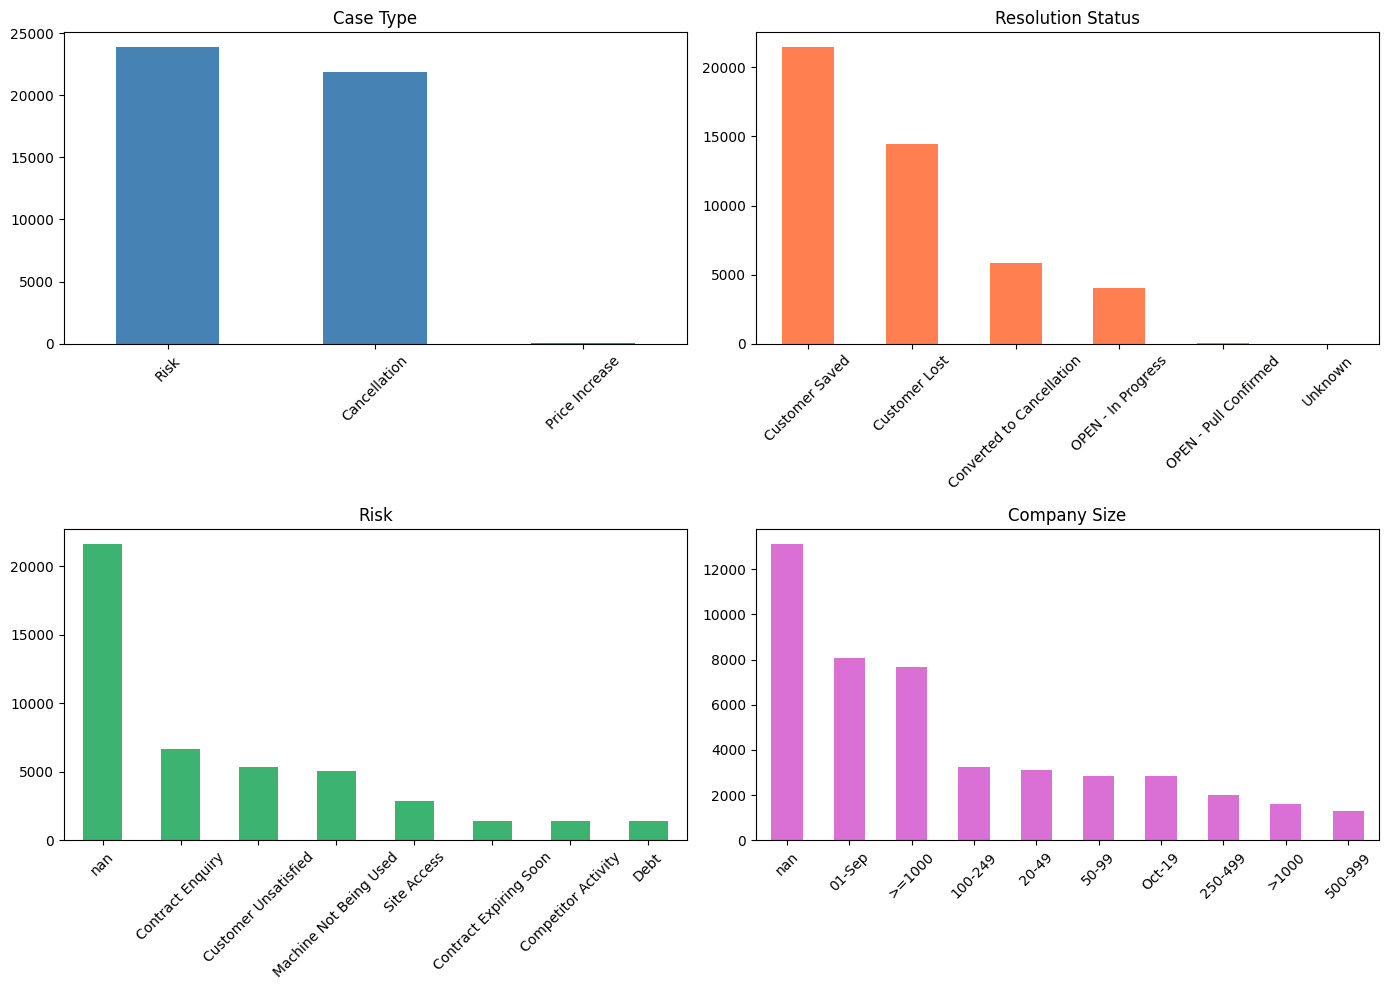

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Case Type
retention["Case Type"].value_counts().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Case Type")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=45)

# Resolution Status
retention["Resolution Status"].value_counts().plot(kind="bar", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Resolution Status")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=45)

# Risk
retention["Risk"].value_counts(dropna=False).plot(kind="bar", ax=axes[1, 0], color="mediumseagreen")
axes[1, 0].set_title("Risk")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=45)

# CompanySize
retention["CompanySize"].value_counts(dropna=False).plot(kind="bar", ax=axes[1, 1], color="orchid")
axes[1, 1].set_title("Company Size")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

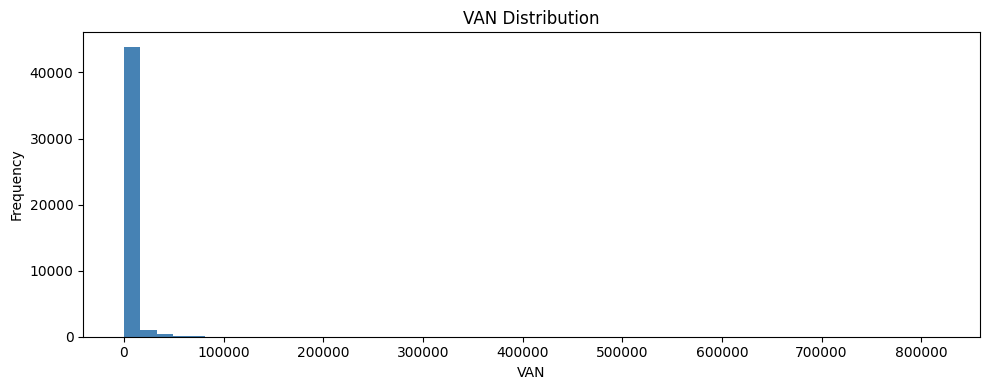

In [62]:
# Distribution of VAN (contract value)
van = retention["VAN"].dropna()
van.plot(kind="hist", bins=50, figsize=(10, 4), color="steelblue", title="VAN Distribution")
plt.xlabel("VAN")
plt.tight_layout()
plt.show()

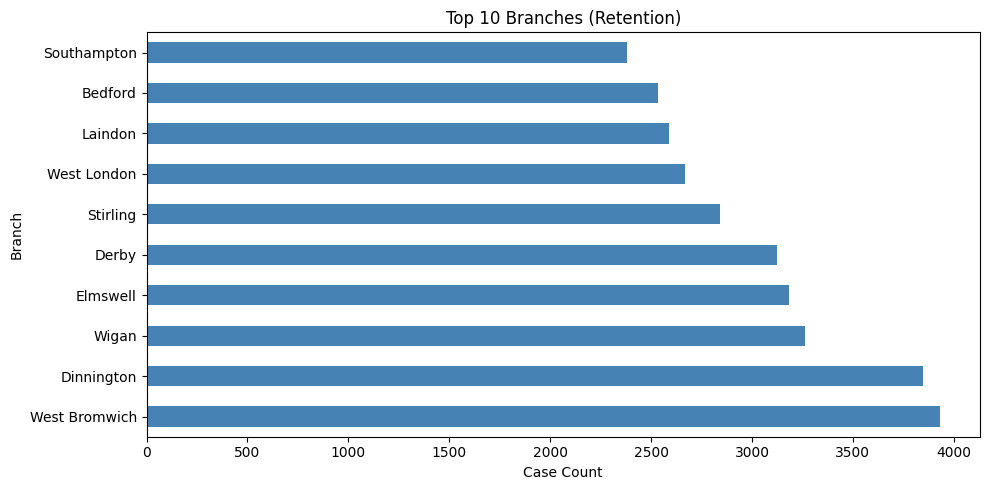

In [63]:
# Top 10 branches by case count
retention["Branch"].value_counts().head(10).plot(
    kind="barh", figsize=(10, 5), color="steelblue", title="Top 10 Branches (Retention)"
)
plt.xlabel("Case Count")
plt.tight_layout()
plt.show()

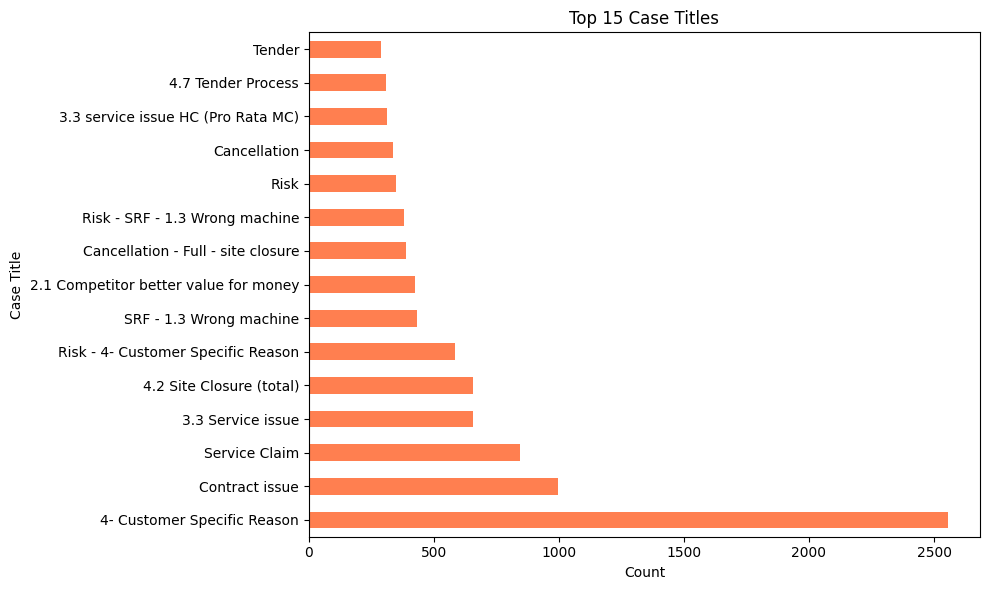

In [64]:
# Top 15 Case Titles
retention["Case Title"].value_counts().head(15).plot(
    kind="barh", figsize=(10, 6), color="coral", title="Top 15 Case Titles"
)
plt.xlabel("Count")
plt.tight_layout()
plt.show()

---
## 2. BoB — Overview

In [65]:
print("Shape:", bob.shape)
bob.head()

Shape: (65883, 26)


,account_number,company_sizing,postal_code,branch,vat_number,agreement_number,agreement_start_date,agreement_end_date,renewal_type,agreement_type,...,bpg,msdyn_product_number,product_name,service_interval,unit_amount,billing_interval,billing_period,machine,machine_variant,chemistry
0,UK02-CGBA029544-L,>1000,PE1 5FQ,Elmswell,Unknown,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Automatic Renewal,Scheduled Billing,...,17. Ultrasonic,ISK400EAA-001483-001,SK400 EAA + 400L of KLEEN7960S + Waste Rustpro...,1.0,9812.14,1.0,monthly,SK400,AA,KLEEN7960S
1,UK02-CGBA029544-L,>1000,PE1 5FQ,Elmswell,Unknown,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Automatic Renewal,Scheduled Billing,...,17. Ultrasonic,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...,1.0,8830.64,1.0,monthly,SK600,AA,KLEEN7960S
2,UK02-CGBA029544-L,>1000,PE1 5FQ,Elmswell,Unknown,GBC4021962-Machine Services-332282,2025-04-14,2028-04-13,Automatic Renewal,Scheduled Billing,...,17. Ultrasonic,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...,1.0,8830.64,1.0,monthly,SK600,AA,KLEEN7960S
3,UK02-CGBA124601-L,20-49,BT71 7ET,Lisburn,GB714768220,GBC4000950-Auto waste,2022-06-24,2026-06-23,Automatic Renewal,Scheduled Billing,...,40. Oil Filters,K0000-040259-000,Waste Paint Sludge Collection - 205,0.0,7686.88,1.0,monthly,NaN,NaN,NaN
4,UK02-CGBA034502-L,50-99,BT41 3UF,Lisburn,Unknown,GBC3028394-Chemistry,2024-11-04,2025-11-03,Automatic Renewal,Scheduled Billing,...,30. Allied Products,C0000-000468-001,Delivery of Std Thinners - 205Ltrs (6),1.0,6933.91,1.0,monthly,NaN,NaN,NaN


In [66]:
bob.dtypes

account_number              str
company_sizing              str
postal_code                 str
branch                      str
vat_number                  str
agreement_number            str
agreement_start_date        str
agreement_end_date          str
renewal_type                str
agreement_type              str
line_of_business            str
system_status               str
product_bob             float64
fee_bob                 float64
total_bob               float64
is_bob                      str
bpg                         str
msdyn_product_number        str
product_name                str
service_interval        float64
unit_amount             float64
billing_interval        float64
billing_period              str
machine                     str
machine_variant             str
chemistry                   str
dtype: object

In [69]:
# Numeric summary
bob.describe()

,product_bob,fee_bob,total_bob,service_interval,unit_amount,billing_interval
count,65883.000000,65883.000000,65883.000000,62785.000000,64152.000000,60805.000000
mean,2524.457354,69.901917,2594.359271,14.186541,231.335357,1.067198
std,3988.967332,178.315267,4023.538485,13.468743,396.203948,0.869876
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,522.480000,0.000000,557.185000,5.000000,46.300000,1.000000
50%,1439.400000,0.000000,1500.000000,9.000000,126.470000,1.000000
75%,2947.140000,96.725000,3050.160000,14.000000,268.415000,1.000000
max,117745.680000,24129.960000,118700.400000,53.000000,9812.140000,52.000000


### Categorical distributions

In [70]:
# Company sizing
bob["company_sizing"].value_counts(dropna=False)

company_sizing
1-9        16324
>1000      14730
20-49       7477
100-249     7216
10-19       6278
50-99       5795
250-499     4289
500-999     2972
NaN          802
Name: count, dtype: int64

In [71]:
# Renewal type
bob["renewal_type"].value_counts(dropna=False)

renewal_type
Automatic Renewal       65273
No Automatic Renewal      610
Name: count, dtype: int64

In [72]:
# Agreement type
bob["agreement_type"].value_counts(dropna=False)

agreement_type
Scheduled Billing    62670
PATOS                 3213
Name: count, dtype: int64

In [73]:
# System status
bob["system_status"].value_counts(dropna=False)

system_status
Active      65483
Estimate      349
Canceled       50
Expired         1
Name: count, dtype: int64

In [74]:
# Line of business
bob["line_of_business"].value_counts(dropna=False)

line_of_business
Machine Services    49790
Auto waste          11052
Oil                  2773
Chemistry            2197
Allied                 60
Kleenwaste             11
Name: count, dtype: int64

In [75]:
# Billing period
bob["billing_period"].value_counts(dropna=False)

billing_period
monthly    60802
NaN         5078
yearly         3
Name: count, dtype: int64

In [76]:
# Top 10 BPG categories
bob["bpg"].value_counts().head(10)

bpg
01. Solvent Parts Cleaners     14234
40. Oil Filters                10937
05. Spray Equipment Cleaner     8412
02. Automated Aqueous Unit      6127
04. Manual Aqueous Cleaner      5882
33. Wipes                       4326
15. Jetkleen                    3823
03. Aqueous Brake Cleaner       2362
30. Allied Products             2255
60. Oil Collector Fees          2196
Name: count, dtype: int64

### Visualisations

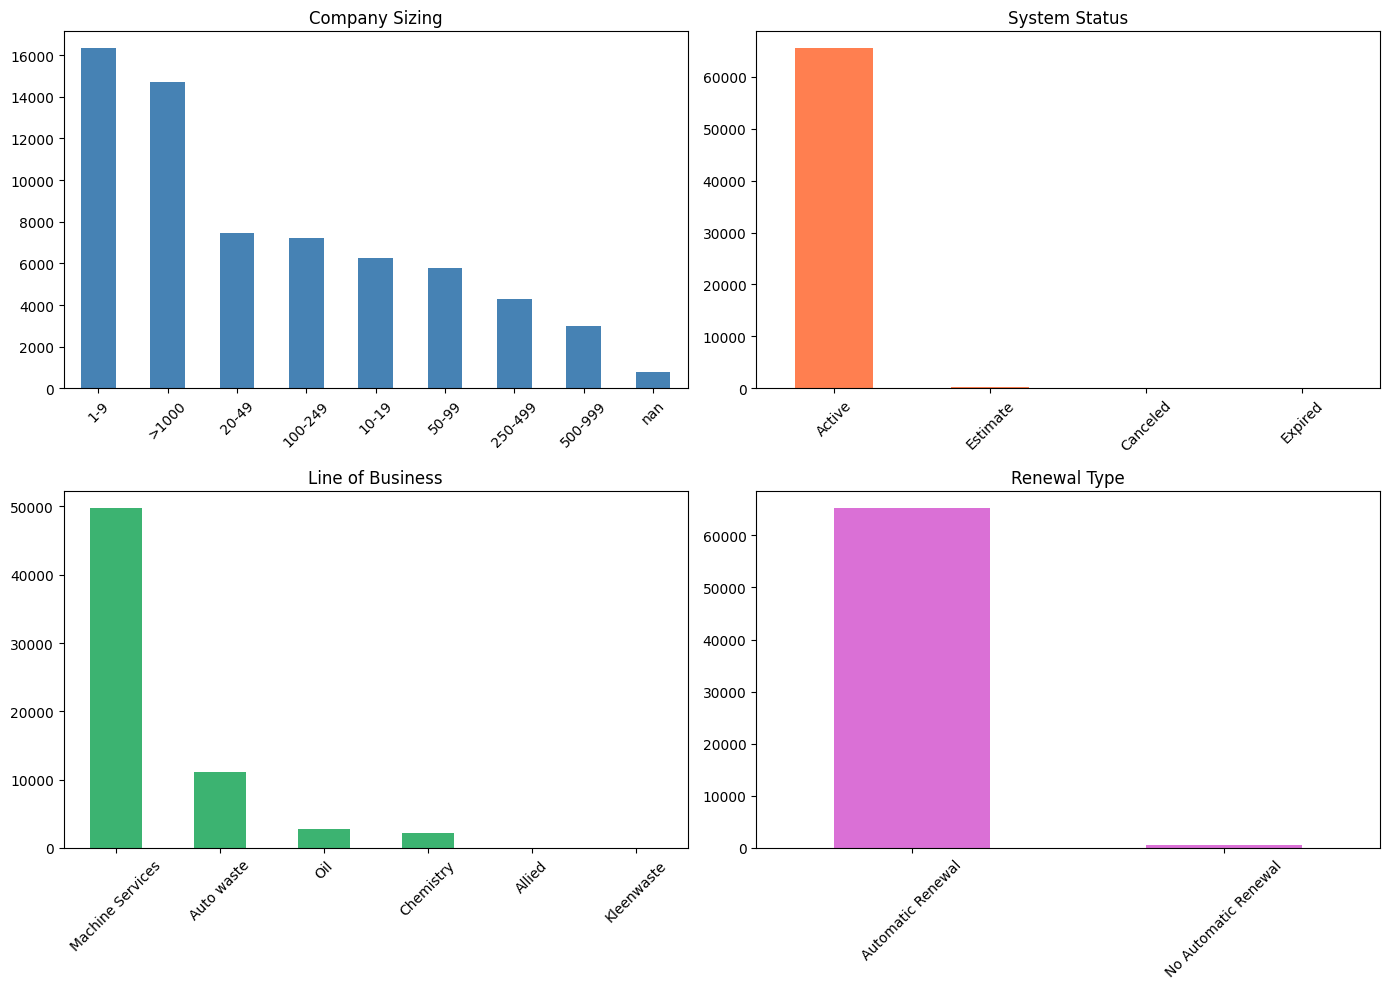

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Company sizing
bob["company_sizing"].value_counts(dropna=False).plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Company Sizing")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=45)

# System status
bob["system_status"].value_counts(dropna=False).plot(kind="bar", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("System Status")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=45)

# Line of business
bob["line_of_business"].value_counts(dropna=False).plot(kind="bar", ax=axes[1, 0], color="mediumseagreen")
axes[1, 0].set_title("Line of Business")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=45)

# Renewal type
bob["renewal_type"].value_counts(dropna=False).plot(kind="bar", ax=axes[1, 1], color="orchid")
axes[1, 1].set_title("Renewal Type")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

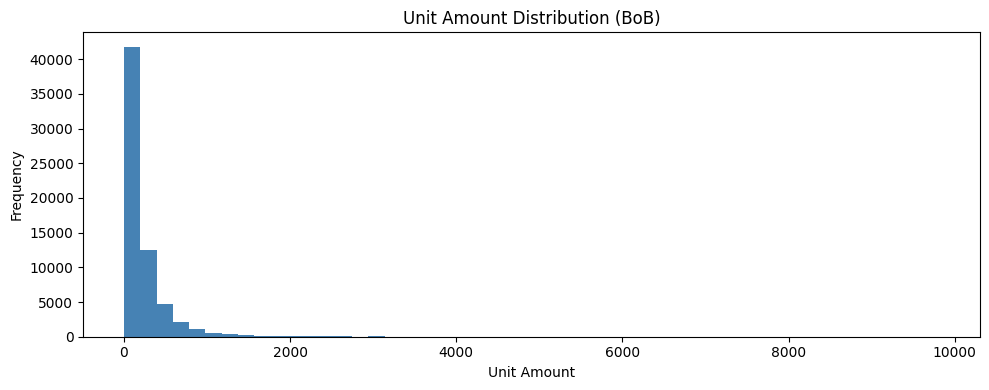

In [78]:
# Unit amount distribution
bob["unit_amount"].dropna().plot(
    kind="hist", bins=50, figsize=(10, 4), color="steelblue", title="Unit Amount Distribution (BoB)"
)
plt.xlabel("Unit Amount")
plt.tight_layout()
plt.show()

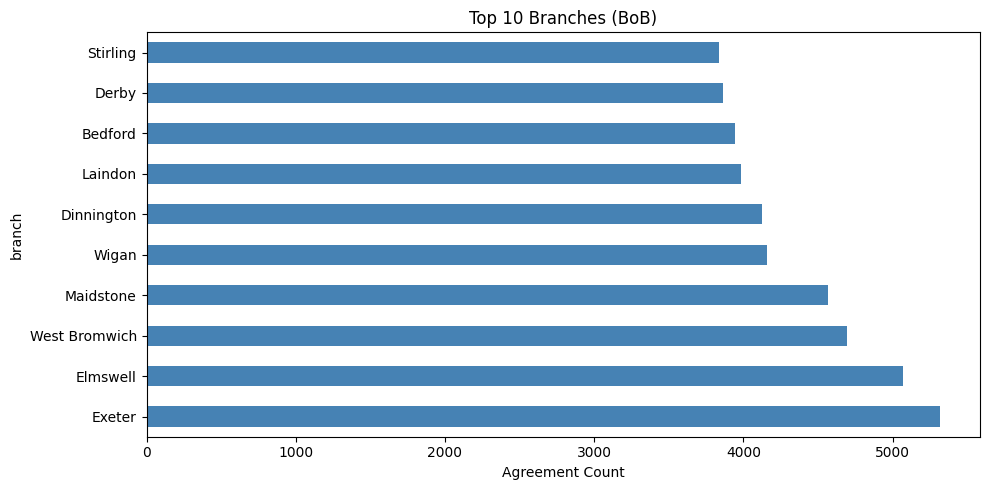

In [79]:
# Top 10 branches by agreement count
bob["branch"].value_counts().head(10).plot(
    kind="barh", figsize=(10, 5), color="steelblue", title="Top 10 Branches (BoB)"
)
plt.xlabel("Agreement Count")
plt.tight_layout()
plt.show()

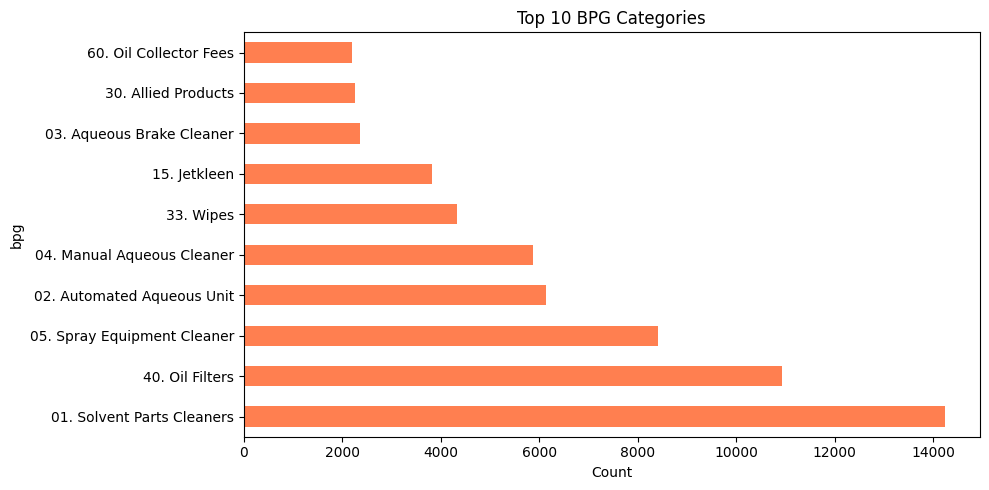

In [80]:
# Top 10 BPG categories
bob["bpg"].value_counts().head(10).plot(
    kind="barh", figsize=(10, 5), color="coral", title="Top 10 BPG Categories"
)
plt.xlabel("Count")
plt.tight_layout()
plt.show()

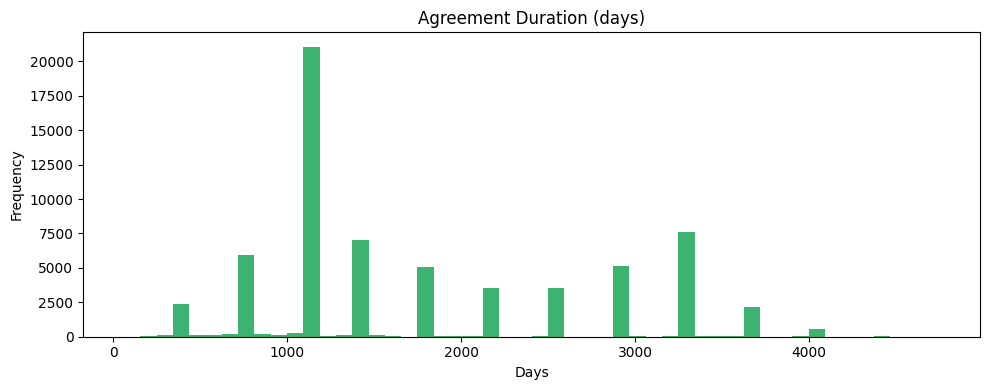

count    65883.000000
mean      1778.976489
std        964.943219
min         61.000000
25%       1095.000000
50%       1460.000000
75%       2556.000000
max       4749.000000
Name: agreement_duration_days, dtype: float64

In [81]:
# Agreement duration in days
bob["agreement_start_date"] = pd.to_datetime(bob["agreement_start_date"])
bob["agreement_end_date"] = pd.to_datetime(bob["agreement_end_date"])
bob["agreement_duration_days"] = (bob["agreement_end_date"] - bob["agreement_start_date"]).dt.days

bob["agreement_duration_days"].dropna().plot(
    kind="hist", bins=50, figsize=(10, 4), color="mediumseagreen", title="Agreement Duration (days)"
)
plt.xlabel("Days")
plt.tight_layout()
plt.show()

bob["agreement_duration_days"].describe()